# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

These tools allow us to model complex, non-linear relationships / non-normal data distributions that standard linear models can't handle. Their primary advantage is the ability to map linear combinations of inputs to a specific range, such as probabilities between 0 and 1.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

These loss functions are effective because they penalize confident but incorrect predictions more severely than Mean Squared Error. This creates a convex optimization surface, and this alignment with MLE leads to faster and more stable convergence during model training.

3. True or false, and explain: Logistic regression is a linear model.

True. It is a Generalized Linear Model (GLM) because the decision boundary is a linear combination of the input features, even though the final output is transformed by a non-linear function.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. While the model technically estimates probabilities, it is one of the most fundamental algorithms used for classification because it applies a decision threshold to those probabilities.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No, the coefficient represents the change in the log-odds of the outcome for a one-unit change in the predictor. To see the change in the actual probability, the coefficient must be interpreted through the logistic function because the relationship is non-linear.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Logistic regression assumes a linear relationship between the predictors and the log-odds (logit), so feature engineering is still essential to capture non-linear patterns or interactions in the data.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. Neither is a universal improvement over the other. OLS is the standard for predicting continuous numerical values, while logistic regression is the appropriate tool for categorical outcomes.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [3]:
# Q2.1 

import pandas as pd
import numpy as np

# Load data with semicolon delimiter
df = pd.read_csv('data/data.csv', sep=';')

# Select relevant variables
cols = ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 
        'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']
df = df[cols]

# Dropping rows with NaNs to ensure model integrity
df = df.dropna()

# Create binary target for Parts 2-5
# 1 = Dropout, 0 = Graduate or Enrolled
df['Binary_Target'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)



In [4]:
# Q2.2 

from sklearn.linear_model import LogisticRegression

X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Binary_Target']

model = LogisticRegression().fit(X, y)
coeffs = pd.DataFrame({'Variable': X.columns, 'Coefficient': model.coef_[0]})
print(coeffs)

                  Variable  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


Debtor and age at enrollment predict a higher dropout probability (positive coefficients), while Tuition fees up to date and Scholarship holder predict a lower probability (negative coefficients). Tuition fees is the strongest coefficient, and this makes sense because being up to date on tuition strongly reduces dropout risk, as financial stability is a huge driver of student retention.

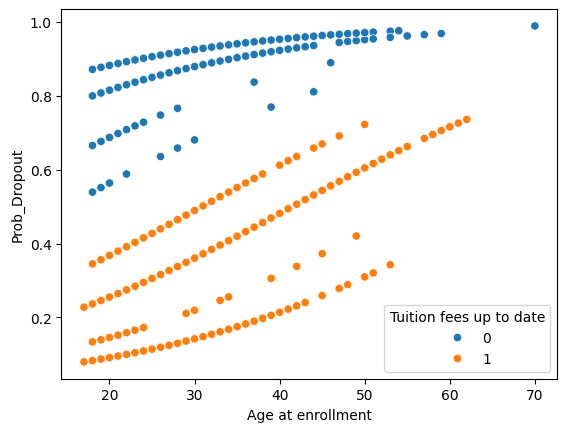

Average change: 0.6125849339965014


In [5]:
# Q2.3 

import seaborn as sns
import matplotlib.pyplot as plt

# Compute probabilities
df['Prob_Dropout'] = model.predict_proba(X)[:, 1]

# Scatter plot
sns.scatterplot(data=df, x='Age at enrollment', y='Prob_Dropout', hue='Tuition fees up to date')
plt.show()

# Calculate average change
avg_prob_uptodate = df[df['Tuition fees up to date'] == 1]['Prob_Dropout'].mean()
avg_prob_not_uptodate = df[df['Tuition fees up to date'] == 0]['Prob_Dropout'].mean()
print(f"Average change: {avg_prob_not_uptodate - avg_prob_uptodate}")


Being up to date on tuition seems to reduce dropout probability the most at ages 18-35. This is where the vertical gap between the blue and orange clusters is at its widest. On average, being up to date on tuition changes the predicted probability of dropout by 61.26%.


In [6]:
# Q2.4

from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)
print(confusion_matrix(y, y_pred))
print(f"Accuracy: {accuracy_score(y, y_pred)}")

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


The accuracy is 76.2%, and this represents the percentage of students correctly classified as either dropout or non-dropout. The confusion matrix shows that it is very good at identifying students who stay enrolled (2,841 to 162), but not good at identifying the dropouts (891 false negatives and 530 true positives).

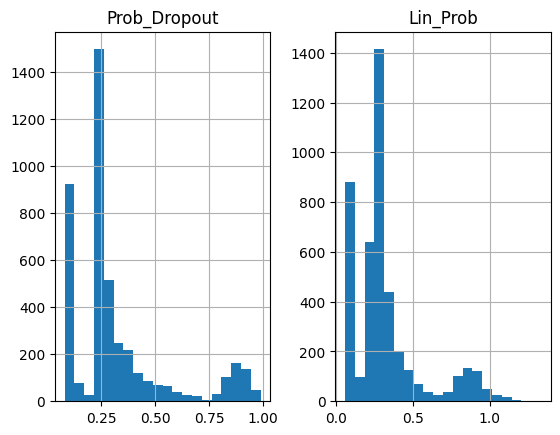

In [7]:
# Q2.5 

from sklearn.linear_model import LinearRegression

# Linear Model
lin_model = LinearRegression().fit(X, y)
df['Lin_Prob'] = lin_model.predict(X)

# Histograms
df[['Prob_Dropout', 'Lin_Prob']].hist(bins=20)
plt.show()

Logistic regression is better for this task because its sigmoid function ensures all predicted probabilities remain within the 0 to 1 range. The linear model fails this requirement by predicting values greater than 1.0, which are impossible in a probability context. Because of this, logistic regression provides a much more accurate and interpretable representation of the underlying dropout risk.

Q2.6 

The students most likely to dropout are those who are older at enrollment, have outstanding debt, and most importantly, are not up to date on their tuition fees. The scatter plot shows that as age increases, students are pushed closer to the dropout threshold because there is less of a safety net for older students.

In [ ]:
# Q2.7
from sklearn.linear_model import LogisticRegression

# Define the specific variables
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

# Fit the multinomial model
multi_model = LogisticRegression(max_iter=1000).fit(X_multi, y_multi)

# Hard Classification (.predict)
y_multi_pred = multi_model.predict(X_multi)

# Predicted Probabilities (.predict_proba)
y_multi_probs = multi_model.predict_proba(X_multi)

# Output for Analysis
print("Unique classes in data:", multi_model.classes_)
print("Unique classes predicted (Hard):", np.unique(y_multi_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_multi, y_multi_pred, labels=multi_model.classes_)
print(cm)

print("\nFirst 5 Predicted Probabilities (Sample):")
# Each row here corresponds to [Prob(Dropout), Prob(Enrolled), Prob(Graduate)]
print(y_multi_probs[:5])

Unique classes in data: ['Dropout' 'Enrolled' 'Graduate']
Unique classes predicted (Hard): ['Dropout' 'Graduate']

Confusion Matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

First 5 Predicted Probabilities (Sample):
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


The confusion matrix shows the model identifies dropouts and graduates well but fails to predict any "Enrolled" students. The hard classification does not predict every class because "Enrolled" is never the most likely label for any individual. The predicted probabilities do include every class, as the underlying math assigns a mathematical likelihood to all three categories for every student. But because "Enrolled" never has the highest probability of the 3, no students are assigned there. 

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [22]:
# Q3.1

# Load data
df = pd.read_csv('data/cirrhosis.csv')

# Select relevant variables
cols = ['Status', 'Edema', 'Drug', 'Bilirubin', 'Stage']
df = df[cols]

# Dropping rows with any NaNs to maintain consistency
df = df.dropna()

# Create binary target for Parts 2-5: 1 = Alive (C or CL), 0 = Dead (D)
df['Survival'] = df['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)

# Encode categorical variables
# Drug: 1 for D-penicillamine, 0 for Placebo
df['Drug_Encoded'] = df['Drug'].map({'D-penicillamine': 1, 'Placebo': 0})

# Edema: Mapping N=0 (none), S=0.5 (resolvable), Y=1 (despite diuretics)
df['Edema_Encoded'] = df['Edema'].map({'N': 0, 'S': 0.5, 'Y': 1})


In [23]:
df.head()

,Status,Edema,Drug,Bilirubin,Stage,Survival,Drug_Encoded,Edema_Encoded
0,D,Y,D-penicillamine,14.5,4.0,0,1,1.0
1,C,N,D-penicillamine,1.1,3.0,1,1,0.0
2,D,S,D-penicillamine,1.4,4.0,0,1,0.5
3,D,S,D-penicillamine,1.8,4.0,0,1,0.5
4,CL,N,Placebo,3.4,3.0,1,0,0.0


In [24]:
# Q3.2

X = df[['Edema_Encoded', 'Drug_Encoded', 'Bilirubin']]
y = df['Survival']

model = LogisticRegression().fit(X, y)
print(pd.DataFrame({'Variable': X.columns, 'Coeff': model.coef_[0]}))

        Variable     Coeff
0  Edema_Encoded -1.467297
1   Drug_Encoded -0.224878
2      Bilirubin -0.350303


The drug does not improve survival probability because the coefficient is negative. Taking the drug is associated with a slightly lower probability of survival compared to the placebo. 

Higher bilirubin predicts a lower survival rate since the coefficient is negative. An increase in bilirubin levels leads to a decrease in survival odds.

Survival probability decreases significantly as edema severity increases, as Edema_Encoded had the largest negative coefficient in the model. This means it is the strongest predictor of mortality among the 3 variables.

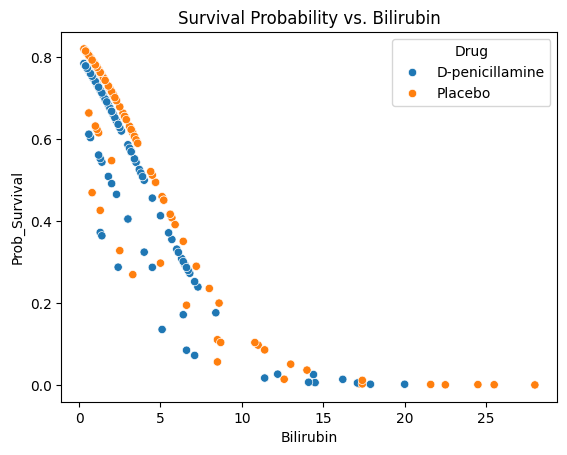

Average Survival Increase from Drug: -0.01889132385002057


In [25]:
# Q3.3 

# Compute probabilities
df['Prob_Survival'] = model.predict_proba(X)[:, 1]

# Scatter plot
sns.scatterplot(data=df, x='Bilirubin', y='Prob_Survival', hue='Drug')
plt.title('Survival Probability vs. Bilirubin')
plt.show()

# Calculate drug impact
avg_survival_drug = df[df['Drug_Encoded'] == 1]['Prob_Survival'].mean()
avg_survival_placebo = df[df['Drug_Encoded'] == 0]['Prob_Survival'].mean()
print(f"Average Survival Increase from Drug: {avg_survival_drug - avg_survival_placebo}")

No values of Bilirubin increase patient survival rate. The orange placebo dots are consistently higher than the blue Bilirubin dots, which signifies a higher survival probability for the control group. 

On average, for patients who take the drug, survival probability decreases by 1.9% compared to the placebo.

In [26]:
# Q3.4 


y_pred = model.predict(X)
print(f"Confusion Matrix:\n{confusion_matrix(y, y_pred)}")
print(f"Accuracy: {accuracy_score(y, y_pred)}")

Confusion Matrix:
[[ 60  65]
 [ 16 171]]
Accuracy: 0.7403846153846154


The accuracy is 74.04%. This indicates how well the model predicts whether a patient is alive or dead after 10 years. This model is much better at identifying survivors (171 true positives) than those who died (65 false positives and 60 true negatives). This means that while the model has a high recall for survivors, it struggles with precision when flagging high-risk patients who ultimately did not survive.

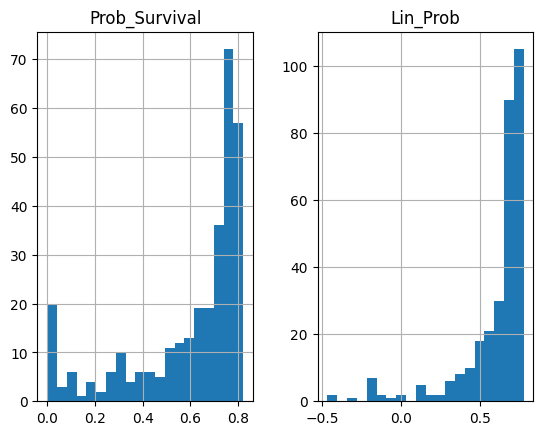

In [27]:
# Q3.5

# Linear Model
lin_model = LinearRegression().fit(X, y)
df['Lin_Prob'] = lin_model.predict(X)

# Histograms
df[['Prob_Survival', 'Lin_Prob']].hist(bins=20)
plt.show()


The logistic regression model correctly constrains all predicted probabilities within the 0 to 1 range, while the linear model predicts negative values, which is impossible. Based on this, it is clear that the logistic regression model is the better model. The linear model captures the general trend, but it is unreliable because it has negative predictions. 

In [28]:
# Q3.6

X_stage = df[['Edema_Encoded', 'Bilirubin']]
y_stage = df['Stage']

multi_model = LogisticRegression(max_iter=2000).fit(X_stage, y_stage)
y_stage_pred = multi_model.predict(X_stage)

print(f"Classes predicted: {np.unique(y_stage_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_stage, y_stage_pred)}")

# Check probabilities
stage_probs = multi_model.predict_proba(X_stage)
print(f"Sample Probabilities:\n{stage_probs[:3]}")


Classes predicted: [3. 4.]
Confusion Matrix:
[[  0   0  16   0]
 [  0   0  61   6]
 [  0   0 102  18]
 [  0   0  74  35]]
Sample Probabilities:
[[8.46853969e-06 3.09408349e-02 1.73328240e-01 7.95722456e-01]
 [7.17164130e-02 2.51794020e-01 4.00913885e-01 2.75575683e-01]
 [4.15970464e-02 1.82450206e-01 3.35664762e-01 4.40287985e-01]]


The confusion matrix shows a model that is biased toward the later phases. It doesn't identify any patients in Stage 1 or Stage 2, and clusters the majority of its predictions into Stage 3, even for patients who are actually in Stage 4. This suggests that the predictors used do not provide enough statistical separation to distinguish between early and intermediate disease stages.

The hard classification does not predict every class (No Stages 1 and 2 apparent). The predicted probabilities, however, does.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

Q4.1
The derivative of the prediction is:

$$\frac{\partial \hat{y}}{\partial x_k} = b_k$$

This means the slope for Xk is independent of x1, x2, and so on.

Q4.2

Using the chain rule and the hint provided:$$\frac{\partial \hat{p}}{\partial x_k} = \frac{\partial \hat{p}}{\partial L} \cdot \frac{\partial L}{\partial x_k} = \hat{p}(1 - \hat{p}) \cdot b_k$$

As X changes, the answer does change. Because the derivative depends on p (which is a function of X), the effect of a feature changes depending on where the sigmoid curve is.

It is different than the part 1 answer because the relationship is non-linear. In Part 1, the effect was a constant line, but not the effect is greatest when the probability is near 0.5 and flattens out as the probability nears the edges (0 or 1).

The max value of the term p(1 - p) occurs when p = 0.5. At this point, the coefficient divided by 4 (bk/4) is a good estimate of how a change in xK affects the actual probability. 

Q4.3

When we look at the model in its "logit" or log-odds form:$$\log\left(\frac{\hat{p}}{1-\hat{p}}\right) = b_0 + b_1x_1 + \dots + b_kx_k$$


A one-unit change in xK affects the log-odds ratio by exactly bK. This matters because while the effect on probability is curvy and complicated (as seen in 4.2), the effect on log-odds is linear and constant. This is why we use this transformation. It allows us to treat a complex probability curve as a simple linear equation.
